In [ ]:
# Load the cleaned data
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/cleaned/sales_data_cleaned.csv")

df["Order_Date"] = pd.to_datetime(df["Order_Date"])

In [3]:
df.head()

,Order_ID,Order_Date,Customer_ID,Product,Category,Region,Quantity,Unit_Price,Discount,Payment_Method,Returned,Sales,Month,Gross_Sales,Discount_Amount,Net_Sales,Month_Name
0,1001,2026-01-03,C001,Laptop,Electronics,North,1,65000,0.05,UPI,No,65000,1,65000,3250.0,61750.0,January
1,1002,2026-01-04,C002,Mouse,Accessories,South,2,800,0.00,Credit Card,No,1600,1,1600,0.0,1600.0,January
2,1003,2026-01-05,C003,Keyboard,Accessories,West,1,1800,0.10,UPI,No,1800,1,1800,180.0,1620.0,January
3,1004,2026-01-06,C004,Monitor,Electronics,East,1,15000,0.05,Debit Card,No,15000,1,15000,750.0,14250.0,January
4,1005,2026-01-08,C005,Headphones,Accessories,North,2,2500,0.00,UPI,Yes,5000,1,5000,0.0,5000.0,January


In [5]:
# pivot_table()
category_region = pd.pivot_table(
    df,
    values="Net_Sales",
    index="Category",
    columns="Region",
    aggfunc="sum",
    fill_value=0
)

category_region

Region,East,North,South,West
Category,,,,
Accessories,2660.0,5000.0,6500.0,8550.0
Electronics,39450.0,77250.0,0.0,64600.0


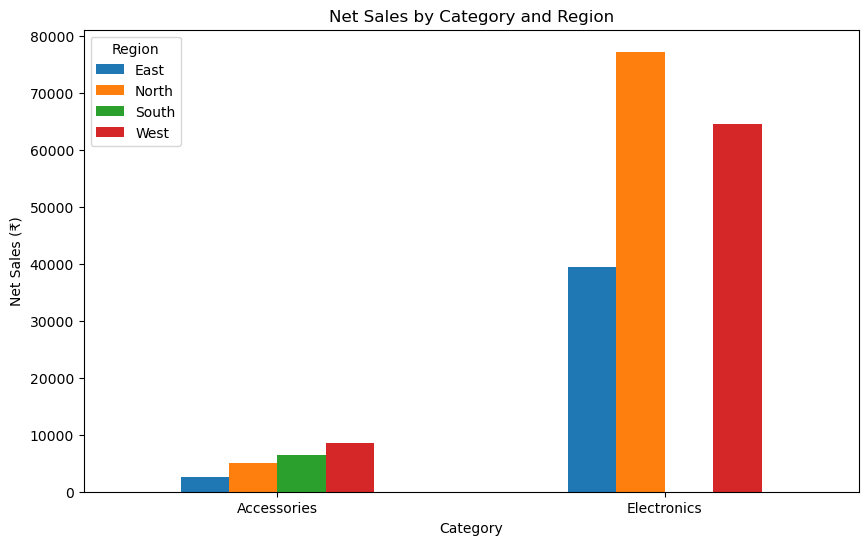

In [6]:
# Visualizing the pivot result
category_region.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Net Sales by Category and Region")
plt.xlabel("Category")
plt.ylabel("Net Sales (₹)")
plt.xticks(rotation=0)

plt.show()

In [7]:
# Are higher discounts associated with higher sales?

In [8]:
df[["Discount", "Net_Sales"]]

,Discount,Net_Sales
0,0.05,61750.0
1,0.00,1600.0
2,0.10,1620.0
3,0.05,14250.0
4,0.00,5000.0
5,0.00,2250.0
6,0.10,25200.0
7,0.00,2800.0
8,0.05,64600.0
9,0.00,15500.0


In [9]:
discount_analysis = (
    df.groupby("Discount")["Net_Sales"]
      .agg(["sum", "mean", "count"])
)

discount_analysis

,sum,mean,count
Discount,,,
0.00,29250.0,4875.0,6
0.05,143260.0,35815.0,4
0.10,31500.0,10500.0,3


In [ ]:
# Correlation
# Correlation asks: Do two numerical variables tend to move together?
# +1  → strong positive relationship
# 0  → little/no linear relationship
# -1  → strong negative relationship
correlation = df["Quantity"].corr(df["Net_Sales"])

print("Quantity vs Net Sales correlation:", correlation)

Quantity vs Net Sales correlation: -0.36486251478846715


In [11]:
# Calculating a correlation matrix
numeric_columns = [
    "Quantity",
    "Unit_Price",
    "Discount",
    "Gross_Sales",
    "Discount_Amount",
    "Net_Sales"
]

correlation_matrix = df[numeric_columns].corr()

correlation_matrix

,Quantity,Unit_Price,Discount,Gross_Sales,Discount_Amount,Net_Sales
Quantity,1.000000,-0.405656,0.008133,-0.360115,-0.256673,-0.364863
Unit_Price,-0.405656,1.000000,0.161502,0.986996,0.874152,0.989745
Discount,0.008133,0.161502,1.000000,0.236067,0.452808,0.222070
Gross_Sales,-0.360115,0.986996,0.236067,1.000000,0.935736,0.999775
Discount_Amount,-0.256673,0.874152,0.452808,0.935736,1.000000,0.928047
Net_Sales,-0.364863,0.989745,0.222070,0.999775,0.928047,1.000000


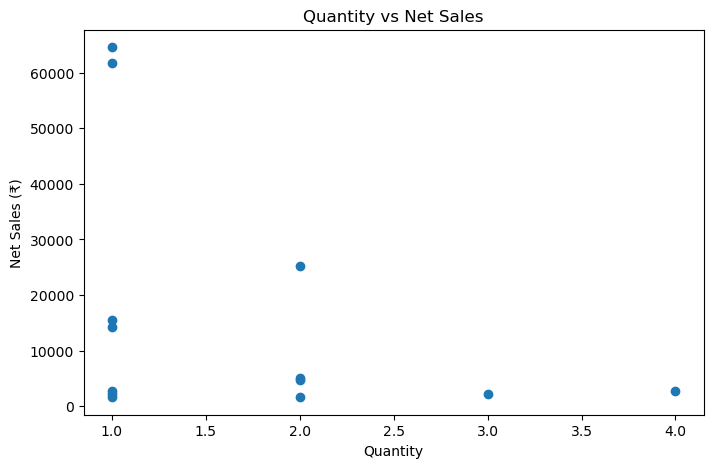

In [12]:
# Scatter Plot
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Quantity"],
    df["Net_Sales"]
)

plt.title("Quantity vs Net Sales")
plt.xlabel("Quantity")
plt.ylabel("Net Sales (₹)")

plt.show()

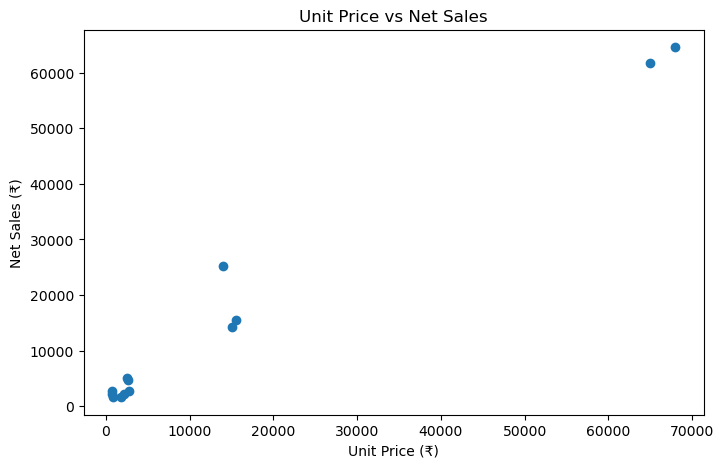

In [13]:
# Unit Price vs Net Sales
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Unit_Price"],
    df["Net_Sales"]
)

plt.title("Unit Price vs Net Sales")
plt.xlabel("Unit Price (₹)")
plt.ylabel("Net Sales (₹)")

plt.show()

In [14]:
price_sales_corr = df["Unit_Price"].corr(df["Net_Sales"])

print(
    "Unit Price vs Net Sales correlation:",
    round(price_sales_corr, 3)
)

Unit Price vs Net Sales correlation: 0.99


In [15]:
# Finding the biggest orders
top_orders = (
    df.sort_values("Net_Sales", ascending=False)
      .head(5)
)

top_orders[
    [
        "Order_ID",
        "Product",
        "Category",
        "Region",
        "Quantity",
        "Discount",
        "Net_Sales"
    ]
]

,Order_ID,Product,Category,Region,Quantity,Discount,Net_Sales
8,1011,Laptop,Electronics,West,1,0.05,64600.0
0,1001,Laptop,Electronics,North,1,0.05,61750.0
6,1008,Monitor,Electronics,East,2,0.10,25200.0
9,1012,Monitor,Electronics,North,1,0.00,15500.0
3,1004,Monitor,Electronics,East,1,0.05,14250.0


In [16]:
# Finding the smallest orders
smallest_orders = (
    df.sort_values("Net_Sales", ascending=True)
      .head(5)
)

smallest_orders[
    [
        "Order_ID",
        "Product",
        "Category",
        "Region",
        "Quantity",
        "Discount",
        "Net_Sales"
    ]
]

,Order_ID,Product,Category,Region,Quantity,Discount,Net_Sales
1,1002,Mouse,Accessories,South,2,0.00,1600.0
2,1003,Keyboard,Accessories,West,1,0.10,1620.0
11,1014,Keyboard,Accessories,South,1,0.00,2100.0
5,1007,Mouse,Accessories,West,3,0.00,2250.0
10,1013,Mouse,Accessories,East,4,0.05,2660.0


In [17]:
print("   DATAPULSE DAY 5  ")

print("\nAverage Order Value:")
print(round(df["Net_Sales"].mean(), 2))

print("\nQuantity vs Net Sales Correlation:")
print(round(df["Quantity"].corr(df["Net_Sales"]), 3))

print("\nUnit Price vs Net Sales Correlation:")
print(round(df["Unit_Price"].corr(df["Net_Sales"]), 3))

print("\nTop Product:")
print(
    df.groupby("Product")["Net_Sales"]
      .sum()
      .idxmax()
)

print("\nTop Region:")
print(
    df.groupby("Region")["Net_Sales"]
      .sum()
      .idxmax()
)

   DATAPULSE DAY 5  

Average Order Value:
15693.08

Quantity vs Net Sales Correlation:
-0.365

Unit Price vs Net Sales Correlation:
0.99

Top Product:
Laptop

Top Region:
North


## Day 5 — Advanced EDA Insights

### Category × Region

The strongest category-region combination was **Electronics in the North region**, generating **₹77,250 in net sales**.

A possible business interpretation is that Electronics products are performing particularly well in the North region. However, the dataset is currently small, so this should be treated as an initial observation rather than a definitive regional trend.

---

### Discount Analysis

The discount analysis showed that orders with a **5% discount generated the highest total net sales (₹143,260)** among the available discount levels.

However, this does **not** mean that a 5% discount causes higher sales. The dataset does not contain enough information to establish causation, and the 5% discount group may contain more high-value orders.

---

### Correlation

**Quantity vs Net Sales correlation: -0.365**

This indicates a moderate negative linear relationship in this small dataset. This is somewhat unexpected because larger quantities do not necessarily correspond to higher revenue here; high-value products can generate much more revenue even with a quantity of one.

**Unit Price vs Net Sales correlation: 0.990**

This indicates a very strong positive relationship between unit price and net sales in this dataset. Since net sales are directly influenced by unit price, this strong relationship is expected.

Correlation shows association, not necessarily causation.

---

### Extreme Orders

The largest orders were primarily **high-value Electronics products**, particularly Laptops and Monitors. The highest-value order was a Laptop order generating **₹64,600 in net sales**.

The smallest orders were mainly **lower-priced Accessories**, particularly Mouse and Keyboard orders, with net sales ranging from approximately **₹1,600 to ₹2,660** among the five smallest orders.

This suggests that product price has a major influence on the difference between high-value and low-value orders.

---

### Key Business Insight

The most interesting finding from today's analysis was that **Electronics products, especially Laptops and Monitors, dominate the high-value sales segment**, while Accessories generate much smaller individual order values.

The strong relationship between Unit Price and Net Sales also suggests that DataPulse's revenue performance is currently heavily influenced by high-ticket products. However, because the current dataset is small, these findings should be validated with a larger dataset before making major business decisions.

In [18]:
plt.savefig("../reports/charts/product_sales_EDA.png", bbox_inches="tight")

<Figure size 640x480 with 0 Axes>